In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import gc

# REEMPLAZA esta lista con las 18 características exactas de tu análisis SHAP
FEATURES_SELECCIONADAS = [
    'iat', 'rst_count', 'urg_count', 'number', 'variance', 'tot_size', 
    'max', 'header_length', 'flow_duration', 'weight', 'rate', 'duration', 
    'protocol_type', 'syn_flag_number', 'fin_count', 'syn_count',
    'rst_flag_number', 'ack_count'
]

In [ ]:
start_time = pd.Timestamp.now()

# 1. Cargar el dataset crudo
print("Cargando dataset completo...")
# Solo cargamos las 46 características + el label para optimizar memoria
df_completo = pd.read_feather("dataset_eda_temp.feather")

# 2. Separar el 10% de Holdout (Simulación de Tráfico Real)
# Al estratificar por 'label' (que es un string multiclase), garantizamos que un 10% 
# exacto de CADA tipo de ataque y del tráfico benigno vaya al archivo de prueba final.
print("Realizando división estratificada (90% Desarrollo / 10% Simulación Real)...")
df_dev, df_real_traffic = train_test_split(
    df_completo, 
    test_size=0.10, 
    random_state=42, 
    stratify=df_completo['label'] 
)

# Guardar el 10% crudo (TRL 4 - Simulación del mundo real)
df_real_traffic.reset_index(drop=True).to_feather("test_real_traffic.feather")
print("10% reservado y guardado como 'test_real_traffic.feather'.")

del df_completo
del df_real_traffic
gc.collect()

# 3. Preprocesamiento del 90% (Desarrollo)
print("Preprocesando el 90% restante...")

# Limpieza de nulos o infinitos solo en las columnas de interés
df_dev = df_dev.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURES_SELECCIONADAS + ['label'])

# CREACIÓN DE LA ETIQUETA BINARIA PARA EL MLP
# IMPORTANTE: Cambia 'BenignTraffic' si en tu dataset el tráfico normal tiene otro nombre (ej. 'Benign', 'Normal')
NOMBRE_CLASE_BENIGNA = 'BenignTraffic'
df_dev['label_binario'] = (df_dev['label'] != NOMBRE_CLASE_BENIGNA).astype(int)

# 4. Balanceo Híbrido Estricto
print("Balanceando el dataset...")
df_benigno = df_dev[df_dev['label_binario'] == 0]
df_malicioso = df_dev[df_dev['label_binario'] == 1]

cantidad_benigno = len(df_benigno)

del df_dev

# Tomar una porción proporcional de CADA TIPO DE ATAQUE original ('label') para igualar la cantidad de tráfico benigno
df_malicioso_balanceado = df_malicioso.groupby('label', group_keys=False).apply(
    lambda x: x.sample(int(np.round(len(x) / len(df_malicioso) * cantidad_benigno)), random_state=42)
)

# Ajuste fino por redondeo
if len(df_malicioso_balanceado) > cantidad_benigno:
    df_malicioso_balanceado = df_malicioso_balanceado.sample(cantidad_benigno, random_state=42)
elif len(df_malicioso_balanceado) < cantidad_benigno:
    faltantes = cantidad_benigno - len(df_malicioso_balanceado)
    df_malicioso_balanceado = pd.concat([df_malicioso_balanceado, df_malicioso.sample(faltantes, random_state=42)])

del df_malicioso

# Unimos y mezclamos el dataset final
df_balanceado = pd.concat([df_benigno, df_malicioso_balanceado]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Cantidad de tráfico benigno: {len(df_benigno)}")
print(f"Cantidad de tráfico malicioso muestreado: {len(df_malicioso_balanceado)}")

del df_malicioso_balanceado

Cargando dataset completo...
Realizando división estratificada (90% Desarrollo / 10% Simulación Real)...
10% reservado y guardado como 'test_real_traffic.feather'.
Preprocesando el 90% restante...
Balanceando el dataset...


C:\Users\caos\AppData\Local\Temp\ipykernel_52708\1007203908.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_malicioso_balanceado = df_malicioso.groupby('label', group_keys=False).apply(


Cantidad de tráfico benigno: 988376
Cantidad de tráfico malicioso muestreado: 988376
90% balanceado y reservado y guardado como 'df_binary_balanced.feather'.
Tiempo total de preprocesamiento: 0 days 00:09:18.004011
PREPROCESAMIENTO FINALIZADO
Dimensión de entrada final: 18 características.
Muestras de entrenamiento: 1581420
Muestras de validación: 197656
Muestras de test interno: 197676


In [2]:
df_balanceado = pd.read_feather("df_binary_balanced.feather")

In [3]:
# 5. División en Train (70%), Val (20%) y Test (10%) interno del subconjunto de desarrollo
X = df_balanceado[FEATURES_SELECCIONADAS].values
y = df_balanceado['label_binario'].values # <-- Aquí le pasamos al modelo solo 0s y 1s

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=2/9, random_state=42, stratify=y_temp)

# 6. Estandarización
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

df_balanceado.reset_index(drop=True).to_feather("df_binary_balanced.feather")
print("90% balanceado y reservado y guardado como 'df_binary_balanced.feather'.")

del df_balanceado
gc.collect()

# end_time = pd.Timestamp.now()
# print(f"Tiempo total de preprocesamiento: {(end_time - start_time)}")

print("==================================================")
print("PREPROCESAMIENTO FINALIZADO")
print(f"Dimensión de entrada final: {X_train.shape[1]} características.")
print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de validación: {len(X_val)}")
print(f"Muestras de test interno: {len(X_test)}")
print("==================================================")

90% balanceado y reservado y guardado como 'df_binary_balanced.feather'.
PREPROCESAMIENTO FINALIZADO
Dimensión de entrada final: 18 características.
Muestras de entrenamiento: 1383725
Muestras de validación: 395351
Muestras de test interno: 197676


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 32)                608       
                                                                 
 activation_3 (Activation)   (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 64)                2112      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 activation_4 (Activation)   (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                      

c:\Users\caos\.conda\envs\ids-iot-train\lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


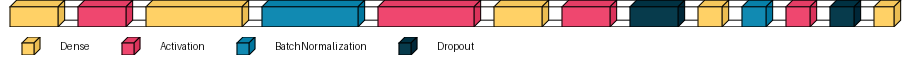

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, BatchNormalization, Dropout
from tensorflow.keras.utils import plot_model

def build_winner_model(input_dim):
    model = Sequential(name="sequential_1")
    
    # Capa 1
    model.add(Dense(32, input_dim=input_dim, name="dense_2"))
    model.add(Activation('relu', name="activation_3"))
    
    # Capa 2
    model.add(Dense(64, name="dense_3"))
    model.add(BatchNormalization(name="batch_normalization_1"))
    model.add(Activation('relu', name="activation_4"))
    
    # Capa 3
    model.add(Dense(32, name="dense_4"))
    model.add(Activation('relu', name="activation_5"))
    model.add(Dropout(0.3, name="dropout_1")) 
    
    # Capa 4
    model.add(Dense(16, name="dense_5"))
    model.add(BatchNormalization(name="batch_normalization_2"))
    model.add(Activation('relu', name="activation_6"))
    model.add(Dropout(0.2, name="dropout_2"))
    
    # Capa de Salida
    model.add(Dense(1, activation='sigmoid', name="dense_6"))
    
    return model

model = build_winner_model(X_train.shape[1])
model.summary()

# Intentar visualización vistosa con visualkeras, si no, fallback a plot_model estético
try:
    import visualkeras
    from PIL import ImageFont
    # Fuente por defecto, si da error se usará la default de visualkeras
    img = visualkeras.layered_view(model, legend=True, spacing=20, scale_xy=1.5)
    img.save('arquitectura_ganadora_binario.png')
    display(img)
except ImportError:
    # plot_model mejorado
    plot_model(model, to_file='arquitectura_ganadora_binario.png', show_shapes=True, show_layer_names=True, show_layer_activations=True, dpi=200, rankdir='LR')
    display(tf.keras.preprocessing.image.load_img('arquitectura_ganadora_binario.png'))

In [5]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Tasa de aprendizaje óptima encontrada por NAS
LEARNING_RATE = 0.001

optimizer = Adam(learning_rate=LEARNING_RATE)

metrics = [
    BinaryAccuracy(name='accuracy'),
    Precision(name='precision'),
    Recall(name='recall'),
    AUC(name='auc')
]

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=metrics)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.4, 
    patience=10, 
    min_lr=1e-6, 
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_binary_model.h5', 
    monitor='val_auc', 
    mode='max', 
    save_best_only=True, 
    verbose=1
)

callbacks_list = [early_stopping, reduce_lr, model_checkpoint]

In [6]:
EPOCHS = 150
BATCH_SIZE = 32 # Tamaño grande para aprovechar GPU RTX y paralelización

start_time = pd.Timestamp.now()

print("Iniciando entrenamiento del modelo...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)
end_time = pd.Timestamp.now()
print(f"Entrenamiento finalizado. Tiempo transcurrido: {(end_time - start_time)}")

Iniciando entrenamiento del modelo...
Epoch 1/150
43237/43242 [============================>.] - ETA: 0s - loss: 0.0340 - accuracy: 0.9922 - precision: 0.9985 - recall: 0.9858 - auc: 0.9972
Epoch 1: val_auc improved from -inf to 0.99820, saving model to best_binary_model.h5
43242/43242 [==============================] - 174s 4ms/step - loss: 0.0340 - accuracy: 0.9922 - precision: 0.9985 - recall: 0.9858 - auc: 0.9972 - val_loss: 0.0272 - val_accuracy: 0.9933 - val_precision: 0.9993 - val_recall: 0.9873 - val_auc: 0.9982 - lr: 0.0010
Epoch 2/150
43234/43242 [============================>.] - ETA: 0s - loss: 0.0285 - accuracy: 0.9931 - precision: 0.9989 - recall: 0.9874 - auc: 0.9979
Epoch 2: val_auc did not improve from 0.99820
43242/43242 [==============================] - 173s 4ms/step - loss: 0.0285 - accuracy: 0.9931 - precision: 0.9989 - recall: 0.9874 - auc: 0.9979 - val_loss: 0.0312 - val_accuracy: 0.9932 - val_precision: 0.9995 - val_recall: 0.9869 - val_auc: 0.9982 - lr: 0.0010

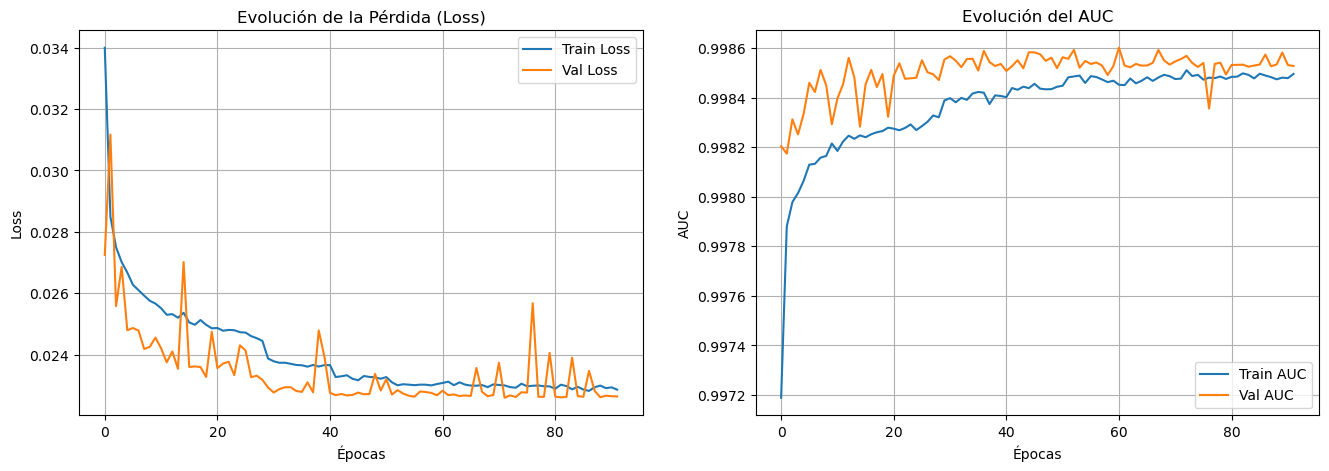


Evaluando modelo en el conjunto de Test (Interno)...
loss: 0.0231
accuracy: 0.9946
precision: 0.9995
recall: 0.9898
auc: 0.9984
6178/6178 [==============================] - 5s 793us/step

--- Reporte de Clasificación ---
               precision    recall  f1-score   support

 Legítimo (0)     0.9899    0.9995    0.9946     98838
Malicioso (1)     0.9995    0.9898    0.9946     98838

     accuracy                         0.9946    197676
    macro avg     0.9947    0.9946    0.9946    197676
 weighted avg     0.9947    0.9946    0.9946    197676



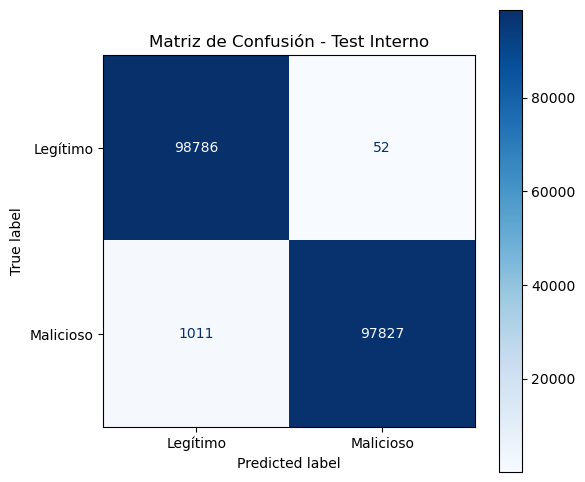

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Gráficas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pérdida
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Evolución de la Pérdida (Loss)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# AUC
axes[1].plot(history.history['auc'], label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('Evolución del AUC')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True)

plt.show()

# 2. Evaluación en el conjunto de Test Interno
print("\nEvaluando modelo en el conjunto de Test (Interno)...")
results = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

# 3. Matriz de Confusión y Reporte
y_pred_probs = model.predict(X_test, batch_size=BATCH_SIZE)
y_pred = (y_pred_probs > 0.5).astype(int)

print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=['Legítimo (0)', 'Malicioso (1)'], digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítimo', 'Malicioso'])
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusión - Test Interno')
plt.show()

In [8]:
# Guardar modelo completo para la siguiente fase de cuantización
MODEL_PATH = "mlp_binario_final.h5"
model.save(MODEL_PATH)
print(f"Modelo guardado exitosamente en: {MODEL_PATH}")

# Guardar el scaler para usarlo en la simulación de tráfico real posteriormente
import joblib
joblib.dump(scaler, 'standard_scaler_binario.pkl')
print("Scaler guardado como 'standard_scaler_binario.pkl'")

print("\n¡Listo! El modelo base está preparado para entrar a la fase de compresión de red neuronal orientada a hardware embebido.")

Modelo guardado exitosamente en: mlp_binario_final.h5
Scaler guardado como 'standard_scaler_binario.pkl'

¡Listo! El modelo base está preparado para entrar a la fase de compresión de red neuronal orientada a hardware embebido.
